In [45]:
# import libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
import pandas as pd

url = "https://github.com/utexas-SDS-357/sds357-project-sp26-cook-the-data-cajun-way/raw/refs/heads/main/stops_clean.csv.gz"

stops = pd.read_csv(url)

stops.head()

C:\Users\Root\AppData\Local\Temp\ipykernel_9772\4028453514.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(url)


,raw_row_number,date,time,location,lat,lng,district,zone,subject_age,subject_race,...,Asian,Native Hawaiian and Other Pacific Islander,Some other race,Male,Female,y_arrest,stop_hour,stop_dow,stop_month,stop_year
0,149223,2012-01-01,46860,Barracks St & N Peters St,29.960840,-90.057711,8,E,35.0,black,...,29.0,0.0,0.0,743.0,543.0,0,0,6,1,2012
1,149149,2012-01-01,47280,Dumaine St & N Rampart St,29.962113,-90.066910,8,E,26.0,white,...,25.0,0.0,0.0,1286.0,784.0,0,0,6,1,2012
2,149086,2012-01-01,4260,S Carrollton Ave & Olive St,29.963036,-90.112752,2,T,27.0,black,...,67.0,0.0,50.0,1035.0,1315.0,0,0,6,1,2012
3,149225,2012-01-01,47520,Barracks St & N Peters St,29.960840,-90.057711,8,E,19.0,white,...,29.0,0.0,0.0,743.0,543.0,0,0,6,1,2012
4,149081,2012-01-01,4380,S Rendon & Washington,29.961357,-90.099890,2,V,67.0,white,...,38.0,0.0,8.0,617.0,1154.0,0,0,6,1,2012


In [47]:
stops.shape

(172993, 72)

In [48]:
stops.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'zone', 'subject_age', 'subject_race', 'subject_sex',
       'officer_assignment', 'type', 'arrest_made', 'citation_issued',
       'warning_issued', 'outcome', 'contraband_found', 'contraband_drugs',
       'contraband_weapons', 'frisk_performed', 'search_conducted',
       'search_person', 'search_vehicle', 'search_basis', 'reason_for_stop',
       'vehicle_color', 'vehicle_make', 'vehicle_model', 'vehicle_year',
       'raw_actions_taken', 'raw_subject_race', 'geometry', 'index_right',
       'STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'Geographic Area Name', 'Total!!Estimate!!Population 25 years and over',
       'Total!!Estimate!!Population 25 years and over!!Less than 9th grade',
       'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma',
       'Total!!Estimate!!Population

### Random Forest

#### arrest or not

In [49]:
# ============================
# Random Forest modeling (stop-level) with tract-aware split
# Target: Arrest vs Not Arrest
# ============================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

from sklearn.ensemble import RandomForestClassifier


# ----------------------------
# 0) ASSUMES you already have a merged stop-level dataframe named `stops`
#    (your notebook creates this after spatial join + ACS merge)
# ----------------------------

# ----------------------------
# 1) Create/verify target
# ----------------------------
# If you already have stops["outcome"] with values including "Arrest", this works:
stops = stops.copy()
if "y_arrest" not in stops.columns:
    if "outcome" in stops.columns:
        stops["y_arrest"] = (stops["outcome"].astype(str).str.lower() == "arrest").astype(int)
    elif "arrest_made" in stops.columns:
        stops["y_arrest"] = stops["arrest_made"].astype(int)
    else:
        raise ValueError("Could not find an arrest indicator. Need either 'outcome' or 'arrest_made'.")

# ----------------------------
# 2) Build time features (if you have a datetime column)
# ----------------------------
# Change 'date' to your datetime column name if different
dt_col = None
for c in ["date", "stop_datetime", "datetime", "stop_date"]:
    if c in stops.columns:
        dt_col = c
        break

if dt_col is not None:
    dt = pd.to_datetime(stops[dt_col], errors="coerce")
    stops["stop_hour"] = dt.dt.hour
    stops["stop_dow"] = dt.dt.dayofweek
    stops["stop_month"] = dt.dt.month
    stops["stop_year"] = dt.dt.year

# ----------------------------
# 3) Define candidate features (only keep ones that exist)
# ----------------------------
# Individual-level predictors
candidate_individual = [
    "subject_race",
    "subject_sex",
    "subject_age",
    "reason_for_stop",     # if you have it
    "violation",           # some SOPP exports use this
    "stop_hour",
    "stop_dow",
    "stop_month",
    "stop_year",
]

# Tract-level (ACS) predictors – adjust names to match your columns
candidate_acs = [
    # income
    'Households!!Estimate!!Mean income (dollars)',
    'Households!!Estimate!!Median income (dollars)',
    # "Mean household income (dollars)",
    # "Median household income (dollars)",
    # race composition (if you computed these)
    '        White', '        Black or African American',
    '        American Indian and Alaska Native',
    '        Asian',
    '        Native Hawaiian and Other Pacific Islander',
    '        Some other race'
    # "perc_black",
    # "perc_white",
    # education bins (examples; replace with your actual column names)
    'Total!!Estimate!!Population 25 years and over',
    'Total!!Estimate!!Population 25 years and over!!Less than 9th grade',
    'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma',
    'Total!!Estimate!!Population 25 years and over!!High school graduate (includes equivalency)',
    'Total!!Estimate!!Population 25 years and over!!Some college, no degree',
    'Total!!Estimate!!Population 25 years and over!!Associate\'s degree',
    'Total!!Estimate!!Population 25 years and over!!Bachelor\'s degree',
    'Total!!Estimate!!Population 25 years and over!!Graduate or professional degree',
    # "Less than 9th grade",
    # "9th to 12th grade, no diploma",
    # "High school graduate (includes equivalency)",
    # "Some college, no degree",
    # "Bachelor's degree",
    # "Graduate or professional degree",
    # total pop (sometimes useful for context)
    "Total population",
]

# Optional: DO NOT include tract id as a feature initially (it can let the model memorize place)
# If you want it later, add "GEOID" to categorical features.
candidate_tract_id = []  # e.g., ["GEOID"]

candidate_features = candidate_individual + candidate_acs + candidate_tract_id
feature_cols = [c for c in candidate_features if c in stops.columns]

if len(feature_cols) == 0:
    raise ValueError("No feature columns found. Check your column names in `stops.columns`.")

# ----------------------------
# 4) Drop rows missing target or group id (GEOID)
# ----------------------------
if "GEOID" not in stops.columns:
    raise ValueError("Need 'GEOID' column for tract-aware splitting. Make sure your ACS merge kept GEOID.")

model_df = stops.dropna(subset=["y_arrest", "GEOID"]).copy()

X = model_df[feature_cols]
y = model_df["y_arrest"].astype(int)
groups = model_df["GEOID"].astype(str)

# ----------------------------
# 5) Preprocessing: impute + one-hot for categoricals
# ----------------------------
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

# ----------------------------
# 6) Tract-aware train/test split (prevents leakage)
# ----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# ----------------------------
# 7) Random Forest model + pipeline
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=None,
    min_samples_leaf=10,
)

pipe_rf_binary = Pipeline(
    steps=[
        ("prep", preprocess),
        ("rf", rf),
    ]
)

pipe_rf_binary.fit(X_train, y_train)

# ----------------------------
# 8) Evaluate
# ----------------------------
y_pred_rf_binary = pipe_rf_binary.predict(X_test)
y_prob_rf_binary = pipe_rf_binary.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf_binary))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf_binary, digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf_binary))
print("Avg Precision (PR AUC):", average_precision_score(y_test, y_prob_rf_binary))

# ----------------------------
# 9) Feature importances (top 25)
# ----------------------------
# Get expanded feature names after preprocessing
prep = pipe_rf_binary.named_steps["prep"]

feature_names = []
if len(num_cols) > 0:
    feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names.extend(ohe_names)

importances = pipe_rf_binary.named_steps["rf"].feature_importances_

fi_rf_binary = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# print("\nTop 25 feature importances:")
# print(fi_rf_binary.head(25).to_string(index=False))
print('\nFeature importances:')
print(fi_rf_binary.to_string(index=False))

# Optional: save feature importance table
# fi.to_csv("rf_feature_importances.csv", index=False)

Confusion matrix:
 [[16639  2290]
 [ 2338  1157]]

Classification report:
               precision    recall  f1-score   support

           0      0.877     0.879     0.878     18929
           1      0.336     0.331     0.333      3495

    accuracy                          0.794     22424
   macro avg      0.606     0.605     0.606     22424
weighted avg      0.792     0.794     0.793     22424

ROC AUC: 0.6964305361855547
Avg Precision (PR AUC): 0.30894624797086745

Feature importances:
                                                                                   feature  importance
                                                                               subject_age    0.175072
                                                                                 stop_year    0.109740
                                                                                stop_month    0.104878
                                                                                  stop_dow  

In [50]:
# rename_dict = {
#     "subject_age": "Subject Age",
#     "stop_month": "Month",
#     "stop_year": "Year",
#     "stop_dow": "Day of Week",
#     "stop_hour": "Hour",
    
#     "subject_race_black": "Driver Race: Black",
#     "subject_race_white": "Driver Race: White",
#     "subject_race_hispanic": "Driver Race: Hispanic",
#     'subject_race_asian/pacific islander': 'Driver Race: Asian/Pacific Islander',
#     'subject_race_unknown': 'Driver Race: Unknown',
#     'subject_race_other': 'Driver Race: Other',
    
#     "subject_sex_male": "Driver Sex: Male",
#     "subject_sex_female": "Driver Sex: Female",

#     "reason_for_stop_TRAFFIC VIOLATION": "Stop Reason: Traffic Violation",
#     "reason_for_stop_SUSPECT PERSON": "Stop Reason: Suspect Person",
#     "reason_for_stop_CRIMINAL VIOLATION": "Stop Reason: Criminal Violation",
#     "reason_for_stop_CALL FOR SERVICE": "Stop Reason: Call for Service",
#     'reason_for_stop_JUVENILE VIOLATION': 'Stop Reason: Juvenile Violation',
#     'reason_for_stop_CITIZEN CONTACT': 'Stop Reason: Citizen Contact',
#     'reason_for_stop_OTHER': 'Stop Reason: Other',
#     'reason_for_stop_SUSPECT VEHICLE': 'Stop Reason: Suspect Vehicle',
#     'reason_for_stop_FLAGGED DOWN': 'Stop Reason: Flagged Down',
#     'reason_for_stop_PRESENT AT CRIME SCENE': 'Stop Reason: Present at Crime Scene',
#     'reason_for_stop_CALL FOR SERVICE|TRAFFIC VIOLATION': 'Stop Reason: Call for Service + Traffic Violation',

#     'Total!!Estimate!!Population 25 years and over!!Some college, no degree': 'Some college, no degree',
#     'Total!!Estimate!!Population 25 years and over!!High school graduate (includes equivalency)': 'High school graduate',
#     'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma': '9th to 12th grade, no diploma',
#     'Total!!Estimate!!Population 25 years and over!!Less than 9th grade': 'Less than 9th grade',
#     'Total!!Estimate!!Population 25 years and over!!Graduate or professional degree': 'Graduate or professional degree',
#     'Total!!Estimate!!Population 25 years and over!!Bachelor\'s degree': 'Bachelor\'s degree',
#     'Total!!Estimate!!Population 25 years and over!!Associate\'s degree': 'Associate\'s degree',

#     'Households!!Estimate!!Mean income (dollars)': 'Mean income (dollars)',
#     'Households!!Estimate!!Median income (dollars)': 'Median income (dollars)',
# }

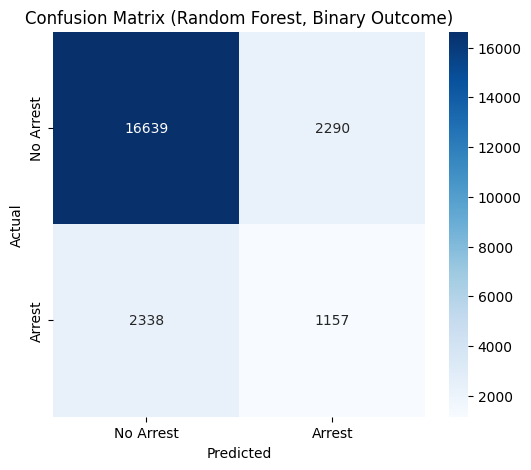

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes = ["No Arrest", 'Arrest']

cm = confusion_matrix(y_test, y_pred_rf_binary)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest, Binary Outcome)")
plt.show()

In [52]:
rename_dict = {
    "subject_age": "Subject Age",
    "stop_month": "Month",
    "stop_year": "Year",
    "stop_dow": "Day of Week",
    "stop_hour": "Hour",
    
    "subject_race_black": "Driver Race: Black",
    "subject_race_white": "Driver Race: White",
    "subject_race_hispanic": "Driver Race: Hispanic",
    'subject_race_asian/pacific islander': 'Driver Race: Asian/Pacific Islander',
    'subject_race_unknown': 'Driver Race: Unknown',
    'subject_race_other': 'Driver Race: Other',
    
    "subject_sex_male": "Driver Sex: Male",
    "subject_sex_female": "Driver Sex: Female",

    "reason_for_stop_TRAFFIC VIOLATION": "Stop Reason: Traffic Violation",
    "reason_for_stop_SUSPECT PERSON": "Stop Reason: Suspect Person",
    "reason_for_stop_CRIMINAL VIOLATION": "Stop Reason: Criminal Violation",
    "reason_for_stop_CALL FOR SERVICE": "Stop Reason: Call for Service",
    'reason_for_stop_JUVENILE VIOLATION': 'Stop Reason: Juvenile Violation',
    'reason_for_stop_CITIZEN CONTACT': 'Stop Reason: Citizen Contact',
    'reason_for_stop_OTHER': 'Stop Reason: Other',
    'reason_for_stop_SUSPECT VEHICLE': 'Stop Reason: Suspect Vehicle',
    'reason_for_stop_FLAGGED DOWN': 'Stop Reason: Flagged Down',
    'reason_for_stop_PRESENT AT CRIME SCENE': 'Stop Reason: Present at Crime Scene',
    'reason_for_stop_CALL FOR SERVICE|TRAFFIC VIOLATION': 'Stop Reason: Call for Service + Traffic Violation',

    'Total!!Estimate!!Population 25 years and over!!Some college, no degree': 'Some college, no degree',
    'Total!!Estimate!!Population 25 years and over!!High school graduate (includes equivalency)': 'High school graduate',
    'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma': '9th to 12th grade, no diploma',
    'Total!!Estimate!!Population 25 years and over!!Less than 9th grade': 'Less than 9th grade',
    'Total!!Estimate!!Population 25 years and over!!Graduate or professional degree': 'Graduate or professional degree',
    'Total!!Estimate!!Population 25 years and over!!Bachelor\'s degree': 'Bachelor\'s degree',
    'Total!!Estimate!!Population 25 years and over!!Associate\'s degree': 'Associate\'s degree',

    'Households!!Estimate!!Mean income (dollars)': 'Mean income (dollars)',
    'Households!!Estimate!!Median income (dollars)': 'Median income (dollars)',
}


fi_rf_binary["feature_clean"] = fi_rf_binary["feature"].replace(rename_dict)

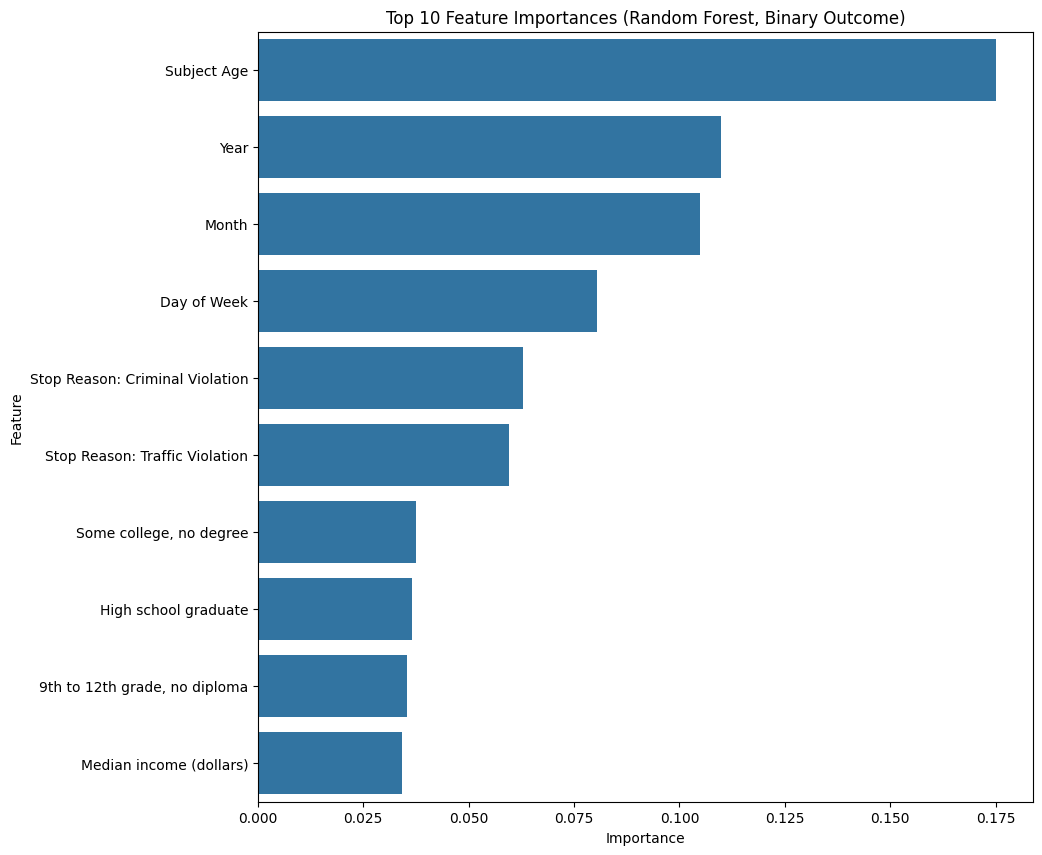

In [53]:
plt.figure(figsize=(10, 10))
sns.barplot(data=fi_rf_binary.head(10), x='importance', y='feature_clean')
plt.title('Top 10 Feature Importances (Random Forest, Binary Outcome)')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

#### which type of arrest

In [54]:
# ============================
# Random Forest (MULTICLASS) outcome model
# Predicts outcome type: None / Warning / Citation / Arrest
# Uses tract-aware split (by GEOID) to reduce leakage
# ============================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
)

# ----------------------------
# 0) Basic checks
# ----------------------------
stops = stops.copy()

if "outcome" not in stops.columns:
    raise ValueError("Expected stops['outcome'] to exist with values like None/Warning/Citation/Arrest.")

if "GEOID" not in stops.columns:
    raise ValueError("Need stops['GEOID'] for tract-aware splitting.")

# Normalize outcome labels
stops["outcome"] = stops["outcome"].astype(str).str.strip()
# If you used "None" as a string label, keep it. If you have NaN, convert it to "None".
stops.loc[stops["outcome"].isin(["nan", "NaN", "NoneType", ""]), "outcome"] = "None"

# Optional: enforce only these 4 outcomes (drop anything else)
allowed = {"None", "Warning", "Citation", "Arrest"}
stops = stops[stops["outcome"].isin(allowed)].copy()

# ----------------------------
# 1) Create time features (if date column exists)
# ----------------------------
dt_col = None
for c in ["date", "stop_datetime", "datetime", "stop_date"]:
    if c in stops.columns:
        dt_col = c
        break

if dt_col is not None:
    dt = pd.to_datetime(stops[dt_col], errors="coerce")
    stops["stop_hour"] = dt.dt.hour
    stops["stop_dow"] = dt.dt.dayofweek
    stops["stop_month"] = dt.dt.month
    stops["stop_year"] = dt.dt.year

# ----------------------------
# 2) Select features
# ----------------------------
# candidate_individual = [
#     "subject_race",
#     "subject_sex",
#     "subject_age",
#     "reason_for_stop",
#     "stop_hour",
#     "stop_dow",
#     "stop_month",
#     "stop_year",
# ]

# # Add tract-level ACS features IF they exist in your merged table
# candidate_acs = [
#     "Mean household income (dollars)",
#     "Median household income (dollars)",
#     "perc_black",
#     "perc_white",
#     # education bins (rename to your exact columns if needed)
#     "Less than 9th grade",
#     "9th to 12th grade, no diploma",
#     "High school graduate (includes equivalency)",
#     "Some college, no degree",
#     "Bachelor's degree",
#     "Graduate or professional degree",
#     "Total population",
# ]

feature_cols = [c for c in (candidate_individual + candidate_acs) if c in stops.columns]
if len(feature_cols) == 0:
    raise ValueError("No feature columns found. Check column names in stops.columns.")

X = stops[feature_cols].copy()
y = stops["outcome"].copy()
groups = stops["GEOID"].astype(str).copy()

# ----------------------------
# 3) Tract-aware train/test split
# ----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# ----------------------------
# 4) Preprocessing: impute + one-hot
# ----------------------------
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

# ----------------------------
# 5) Random Forest (multiclass)
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=10,
)

pipe_rf_multiclass = Pipeline(steps=[("prep", preprocess), ("rf", rf)])
pipe_rf_multiclass.fit(X_train, y_train)

# ----------------------------
# 6) Evaluate
# ----------------------------
y_pred_rf_multiclass = pipe_rf_multiclass.predict(X_test)
y_prob_rf_multiclass = pipe_rf_multiclass.predict_proba(X_test)   # shape: (n, n_classes)
classes = pipe_rf_multiclass.named_steps["rf"].classes_

print("Classes:", classes)
print("\nConfusion matrix (rows=actual, cols=pred):")
print(confusion_matrix(y_test, y_pred_rf_multiclass, labels=classes))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf_multiclass, digits=3))

# Multiclass log loss (lower is better)
print("Log loss:", log_loss(y_test, y_prob_rf_multiclass, labels=classes))

# Multiclass ROC AUC (OvR) – only works well if all classes present in y_test
try:
    auc_ovr = roc_auc_score(
        pd.get_dummies(y_test).reindex(columns=classes, fill_value=0).values,
        y_prob_rf_multiclass,
        multi_class="ovr"
    )
    print("ROC AUC (OvR):", auc_ovr)
except Exception as e:
    print("ROC AUC (OvR) not computed:", e)

# Average precision per class (one-vs-rest)
# (Helpful if Arrest is rare)
y_test_bin = pd.get_dummies(y_test).reindex(columns=classes, fill_value=0)
ap_per_class = {}
for i, cls in enumerate(classes):
    try:
        ap_per_class[cls] = average_precision_score(y_test_bin[cls], y_prob_rf_multiclass[:, i])
    except Exception:
        ap_per_class[cls] = np.nan

print("\nAverage Precision (PR AUC) per class:")
for k, v in ap_per_class.items():
    print(f"  {k}: {v}")

# ----------------------------
# 7) Feature importances (top 30)
# ----------------------------
prep = pipe_rf_multiclass.named_steps["prep"]

feature_names = []
if len(num_cols) > 0:
    feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    feature_names.extend(ohe.get_feature_names_out(cat_cols).tolist())

importances = pipe_rf_multiclass.named_steps["rf"].feature_importances_
fi_rf_multiclass = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 30 feature importances:")
print(fi_rf_multiclass.head(30).to_string(index=False))

# Optional: save
# fi.to_csv("rf_multiclass_feature_importances.csv", index=False)

Classes: ['Arrest' 'Citation' 'None' 'Warning']

Confusion matrix (rows=actual, cols=pred):
[[ 835  614  935 1111]
 [ 808 2077  626 3827]
 [ 357  401 2889  721]
 [ 463 1480  954 4326]]

Classification report:
              precision    recall  f1-score   support

      Arrest      0.339     0.239     0.280      3495
    Citation      0.454     0.283     0.349      7338
        None      0.535     0.661     0.591      4368
     Warning      0.433     0.599     0.503      7223

    accuracy                          0.452     22424
   macro avg      0.440     0.446     0.431     22424
weighted avg      0.445     0.452     0.435     22424

Log loss: 1.1949476971937656
ROC AUC (OvR): 0.7110254598503698

Average Precision (PR AUC) per class:
  Arrest: 0.3077213923301805
  Citation: 0.45516924033318484
  None: 0.549663843370643

Top 30 feature importances:
                                                                                   feature  importance
                                   

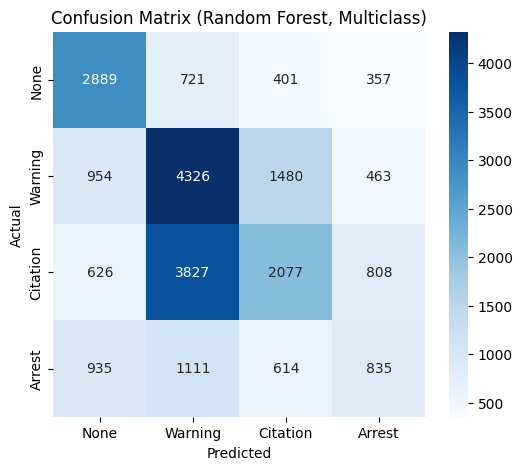

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = ['None', 'Warning', 'Citation', 'Arrest']
cm = confusion_matrix(y_test, y_pred_rf_multiclass, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest, Multiclass)")
plt.show()

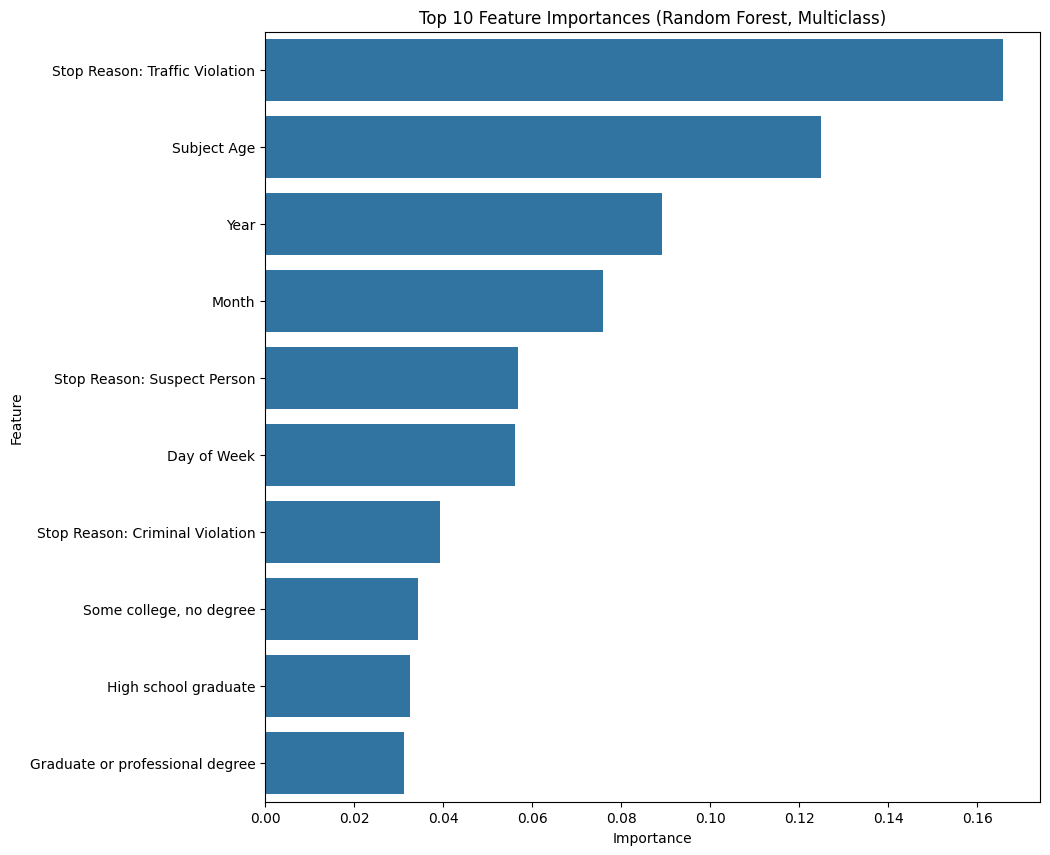

In [56]:
fi_rf_multiclass["feature_clean"] = fi_rf_multiclass["feature"].replace(rename_dict)

plt.figure(figsize=(10, 10))
sns.barplot(data=fi_rf_multiclass.head(10), x='importance', y='feature_clean')
plt.title('Top 10 Feature Importances (Random Forest, Multiclass)')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Multinomial Logistic Regression

In [57]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot


#pulling out relevant variables
clean_stops = stops[['outcome', 'subject_age', 'subject_race', 'subject_sex', 'lat', 'lng', 'stop_hour', 'stop_month']].copy()
clean_stops['outcome'] = clean_stops['outcome'].fillna('None')
clean_stops = clean_stops.dropna()

#encoding predictors
X = clean_stops.drop(columns=['outcome'])
X = pd.get_dummies(X, drop_first=True)

#response
y = clean_stops['outcome']

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#fit the model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)


#prediction
y_pred = model.predict(X_test)
probs = model.predict_proba(X_test)

c:\Users\Root\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Root\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Arrest       0.33      0.00      0.01      5469
    Citation       0.39      0.57      0.46     11313
        None       0.00      0.00      0.00      5777
     Warning       0.34      0.53      0.42     10839

    accuracy                           0.37     33398
   macro avg       0.27      0.28      0.22     33398
weighted avg       0.30      0.37      0.29     33398



c:\Users\Root\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Root\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Root\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif